# Analyse training FSDP rank 128

Ce notebook parse le log `tqdm` de training, extrait `loss`, `lr` et `sec/it`, puis trace les courbes utiles pour diagnostiquer la convergence.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LOG_PATH = PROJECT_ROOT / "train_logs" / "fsdp_rank128_cpu_offload.log"
LOG_PATH

PosixPath('/home/ens.old/Bpokrzywa/expression_identity_gen/train_logs/fsdp_rank128_cpu_offload.log')

In [2]:
def parse_duration_to_seconds(value: str) -> float:
    parts = value.split(":")
    if len(parts) == 1:
        return float(parts[0])
    if len(parts) == 2:
        minutes, seconds = parts
        return int(minutes) * 60 + float(seconds)
    hours, minutes, seconds = parts
    return int(hours) * 3600 + int(minutes) * 60 + float(seconds)


def parse_training_log(log_path: Path, total_steps: int | None = None) -> pd.DataFrame:
    text = log_path.read_text(errors="replace")

    if total_steps is None:
        total_matches = re.findall(r"\|\s*\d+/(\d+)\s*\[", text)
        if not total_matches:
            raise ValueError("Could not infer total step count from tqdm log.")
        total_steps = max(int(x) for x in total_matches)

    pattern = re.compile(
        rf"training:\s*\d+%\|[^\r\n]*?\|\s*"
        rf"(\d+)/{total_steps}\s*"
        rf"\[([^<\],]+)<[^,\]]*,\s*"
        rf"([0-9.]+)s/it,\s*"
        rf"loss=([0-9.]+),\s*"
        rf"lr=([0-9.eE+-]+)\]"
    )

    # tqdm writes repeated refreshes on one carriage-return line. Keep the last loss/lr per step.
    by_step = {}
    for step, elapsed, sec_per_it, loss, lr in pattern.findall(text):
        by_step[int(step)] = {
            "step": int(step),
            "elapsed": elapsed,
            "elapsed_sec": parse_duration_to_seconds(elapsed),
            "sec_per_it": float(sec_per_it),
            "loss": float(loss),
            "lr": float(lr),
        }

    df = pd.DataFrame([by_step[k] for k in sorted(by_step)])
    if df.empty:
        raise ValueError(f"No loss records parsed from {log_path}")

    df["loss_ma50"] = df["loss"].rolling(50, min_periods=1).mean()
    df["loss_ma100"] = df["loss"].rolling(100, min_periods=1).mean()
    df["loss_ma250"] = df["loss"].rolling(250, min_periods=1).mean()
    df["sec_per_it_ma50"] = df["sec_per_it"].rolling(50, min_periods=1).mean()
    return df


df = parse_training_log(LOG_PATH)
df.head(), df.tail(), df.shape

(   step elapsed  elapsed_sec  sec_per_it     loss      lr  loss_ma50  \
 0     1   01:29         89.0       89.34  0.04420  0.0001   0.044200   
 1     2   02:30        150.0       72.89  0.07453  0.0001   0.059365   
 2     3   03:31        211.0       67.16  0.08372  0.0001   0.067483   
 3     4   04:32        272.0       64.71  0.04931  0.0001   0.062940   
 4     5   07:00        420.0       94.99  0.07771  0.0001   0.065894   
 
    loss_ma100  loss_ma250  sec_per_it_ma50  
 0    0.044200    0.044200        89.340000  
 1    0.059365    0.059365        81.115000  
 2    0.067483    0.067483        76.463333  
 3    0.062940    0.062940        73.525000  
 4    0.065894    0.065894        77.818000  ,
       step   elapsed  elapsed_sec  sec_per_it     loss            lr  \
 2995  2996  60:37:47     218267.0       60.84  0.04964  4.390000e-10   
 2996  2997  60:38:52     218332.0       62.12  0.03221  2.470000e-10   
 2997  2998  60:39:51     218391.0       61.11  0.02810  1.10000

In [3]:
summary = pd.Series({
    "steps_parsed": len(df),
    "first_step": int(df.step.min()),
    "last_step": int(df.step.max()),
    "loss_mean": df.loss.mean(),
    "loss_median": df.loss.median(),
    "loss_std": df.loss.std(ddof=0),
    "loss_min": df.loss.min(),
    "loss_min_step": int(df.loc[df.loss.idxmin(), "step"]),
    "loss_max": df.loss.max(),
    "loss_max_step": int(df.loc[df.loss.idxmax(), "step"]),
    "final_loss": df.loss.iloc[-1],
    "final_lr": df.lr.iloc[-1],
    "median_sec_per_it": df.sec_per_it.median(),
    "total_elapsed_hours": df.elapsed_sec.iloc[-1] / 3600,
})
summary

steps_parsed           3000.000000
first_step                1.000000
last_step              3000.000000
loss_mean                 0.047859
loss_median               0.047080
loss_std                  0.014474
loss_min                  0.009620
loss_min_step          2315.000000
loss_max                  0.105990
loss_max_step           373.000000
final_loss                0.041510
final_lr                  0.000000
median_sec_per_it        61.300000
total_elapsed_hours      60.697500
dtype: float64

In [4]:
windows = [(1, 100), (101, 500), (501, 1000), (1001, 1500), (1501, 2000), (2001, 2500), (2501, 3000)]
rows = []
for start, end in windows:
    chunk = df[(df.step >= start) & (df.step <= end)]
    if chunk.empty:
        continue
    rows.append({
        "window": f"{start}-{end}",
        "n": len(chunk),
        "loss_mean": chunk.loss.mean(),
        "loss_median": chunk.loss.median(),
        "loss_min": chunk.loss.min(),
        "loss_max": chunk.loss.max(),
        "loss_std": chunk.loss.std(ddof=0),
        "lr_start": chunk.lr.iloc[0],
        "lr_end": chunk.lr.iloc[-1],
        "sec_per_it_median": chunk.sec_per_it.median(),
    })

window_stats = pd.DataFrame(rows)
window_stats

,window,n,loss_mean,loss_median,loss_min,loss_max,loss_std,lr_start,lr_end,sec_per_it_median
0,1-100,100,0.055297,0.053980,0.03070,0.09460,0.013064,0.000100,0.000100,205.565
1,101-500,400,0.054505,0.054205,0.01644,0.10599,0.014653,0.000100,0.000093,62.665
2,501-1000,500,0.048721,0.047935,0.01396,0.09393,0.014092,0.000093,0.000075,61.850
3,1001-1500,500,0.047233,0.046630,0.01238,0.09794,0.014012,0.000075,0.000050,60.985
4,1501-2000,500,0.046295,0.045315,0.01492,0.08630,0.013640,0.000050,0.000025,60.555
5,2001-2500,500,0.045487,0.043615,0.00962,0.08753,0.014520,0.000025,0.000007,60.590
6,2501-3000,500,0.044754,0.043910,0.01411,0.08682,0.013928,0.000007,0.000000,61.740


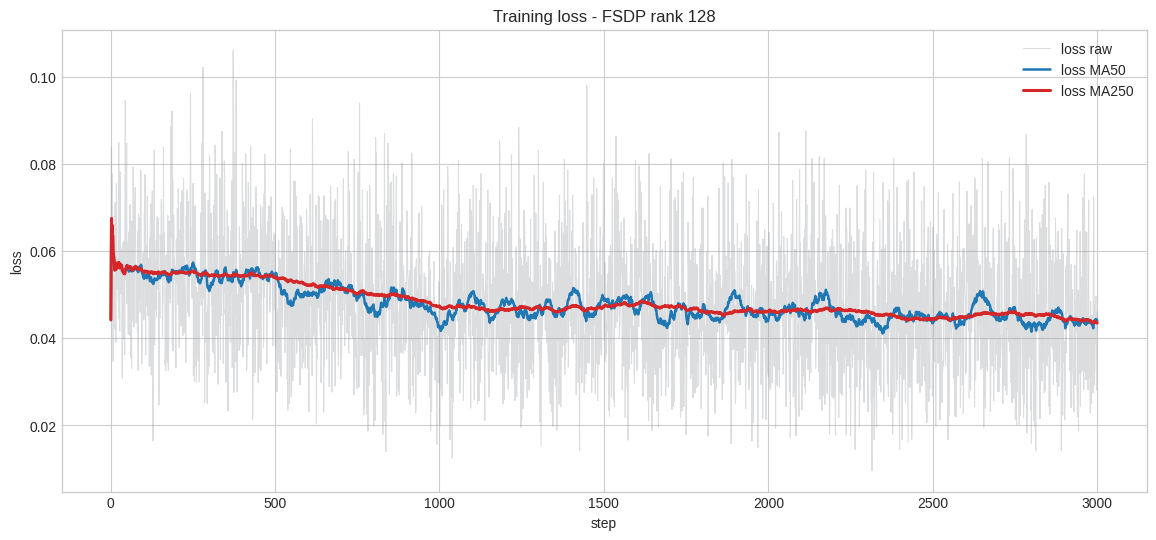

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.step, df.loss, color="#9aa0a6", alpha=0.35, linewidth=0.8, label="loss raw")
ax.plot(df.step, df.loss_ma50, color="#1f77b4", linewidth=1.8, label="loss MA50")
ax.plot(df.step, df.loss_ma250, color="#d62728", linewidth=2.2, label="loss MA250")
ax.set_title("Training loss - FSDP rank 128")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.step, df.loss_ma100, color="#1f77b4", linewidth=2, label="loss MA100")
axes[0].scatter(df.step, df.loss, color="#9aa0a6", alpha=0.16, s=8, label="loss raw")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(df.step, df.lr, color="#2ca02c", linewidth=2)
axes[1].set_xlabel("step")
axes[1].set_ylabel("learning rate")
axes[1].set_yscale("symlog", linthresh=1e-10)

fig.suptitle("Loss vs learning rate")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.step, df.sec_per_it, color="#9aa0a6", alpha=0.25, linewidth=0.8, label="sec/it raw")
ax.plot(df.step, df.sec_per_it_ma50, color="#9467bd", linewidth=2, label="sec/it MA50")
ax.axhline(df.sec_per_it.iloc[500:].median(), color="#d62728", linestyle="--", linewidth=1.5, label="median after step 500")
ax.set_title("Temps par itération")
ax.set_xlabel("step")
ax.set_ylabel("seconds / iteration")
ax.legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df.loss, bins=50, color="#1f77b4", alpha=0.82)
axes[0].axvline(df.loss.mean(), color="#d62728", linestyle="--", label=f"mean={df.loss.mean():.4f}")
axes[0].axvline(df.loss.median(), color="#2ca02c", linestyle="--", label=f"median={df.loss.median():.4f}")
axes[0].set_title("Distribution de la loss")
axes[0].set_xlabel("loss")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].boxplot(
    [df[(df.step >= start) & (df.step <= end)].loss for start, end in windows if not df[(df.step >= start) & (df.step <= end)].empty],
    labels=[f"{start}-{end}" for start, end in windows if not df[(df.step >= start) & (df.step <= end)].empty],
    showfliers=False,
)
axes[1].set_title("Loss par fenêtre de steps")
axes[1].set_xlabel("window")
axes[1].set_ylabel("loss")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [ ]:
thresholds = [0.02, 0.03, 0.05, 0.08, 0.10, 0.12]
threshold_stats = pd.DataFrame({
    "threshold": thresholds,
    "count_below": [(df.loss < t).sum() for t in thresholds],
    "pct_below": [(df.loss < t).mean() * 100 for t in thresholds],
    "count_above": [(df.loss > t).sum() for t in thresholds],
    "pct_above": [(df.loss > t).mean() * 100 for t in thresholds],
})
threshold_stats

In [ ]:
text = LOG_PATH.read_text(errors="replace").lower()
diagnostics = pd.Series({
    "nan_count": text.count("nan"),
    "inf_count": text.count("inf"),
    "oom_count": text.count("oom"),
    "error_count": text.count("error"),
    "traceback_count": text.count("traceback"),
})
diagnostics

## Lecture rapide

- Si `loss_ma250` baisse nettement: apprentissage visible dans la loss.
- Si `loss_ma250` reste plate: la loss est surtout bruitée; il faut comparer les samples/checkpoints.
- Si `sec/it` baisse après les premiers steps: warm-up/cache/dataloader/allocations CUDA stabilisés.
- Si `nan_count`, `oom_count` ou `traceback_count` sont non nuls: inspecter les lignes correspondantes dans le log brut.